# VIX9D-Term — does the *short end* of the VIX curve time the market?
### The 9-day vs 30-day contango/backwardation slope as a risk-off timer, tested honestly

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_buy-and-hold%3F: No](https://img.shields.io/badge/Beats_buy--and--hold%3F-No-8b949e?style=flat-square)

Two volatility numbers sit at the front of the curve: **^VIX9D** (9-day implied vol) and **^VIX** (30-day). The 9-day tenor is the twitchiest point on the whole volatility surface — it reacts to *this afternoon's* headline. When ^VIX9D < ^VIX the front end slopes up (*contango*, the normal calm state); when ^VIX9D spikes *above* ^VIX the very short end *inverts* into backwardation, and vol-traders read it as acute near-term fear — a classic risk-off alert. The ratio log(^VIX / ^VIX9D) is tracked as a clean, continuous signal. This notebook asks the only question that matters: **does an inverted front end actually tell you the S&P is about to fall?**

> **This is the plain-language layer.** Want the quintile tables, the HAC t-stats and the cost maths? That's **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> **Not investment advice.** A reproducible research tool: every chart is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from vix9d_term import data, strategy as st

# Frozen real-tape headline numbers — mirror of docs/results.md (as-of 2026-07-12).
R = dict(
    n=3901, date_start="2011-01-04", date_end="2026-07-10", fp="5953babc50d3",
    frac_contango=0.731,
    spread_1d=-2.79, t_spread_1d=-0.35,
    spread_5d=-10.25, t_spread_5d=-0.36,
    spread_21d=-67.86, t_spread_21d=-1.10,
    q1_mean=8.73, q1_t=1.65, q2_mean=5.16, q2_t=1.33,
    q3_mean=2.68, q3_t=0.79, q4_mean=3.25, q4_t=1.17, q5_mean=5.94, q5_t=2.80,
    active_mean=3.64, active_sharpe=0.83, active_t=3.41,
    passive_mean=5.27, passive_sharpe=0.78, passive_t=3.42,
    spread_mean=-1.64, spread_t=-1.45, switches_yr=37.0, spread_ann=-4.1,
    n_contango=2851, pct_contango=73.1, mean_contango=4.97, sharpe_contango=0.97,
    n_back=1048, pct_back=26.9, mean_back=6.04, sharpe_back=0.60,
)

def _have_cache():
    return os.path.exists(data._cache_path(data.DEFAULT_CACHE))

HAVE_REAL = _have_cache()
print("real daily cache present:", HAVE_REAL)


real daily cache present: True


In [2]:
if HAVE_REAL:
    df = data.fetch_daily(fetch=False)
    print(f"Tape: N={len(df)}, {df.index[0].date()} to {df.index[-1].date()}")
    print(f"Fraction contango: {(df['slope']>0).mean():.3f}")


Tape: N=3901, 2011-01-04 to 2026-07-10
Fraction contango: 0.731


## The answer first

| Question | Answer |
|---|---|
| Does steep contango predict *better* SPY returns? | **No.** The Q5 (steepest contango) minus Q1 (deepest backwardation) spread is **-2.79 bps** at 1 day — *wrong sign*, *t* = -0.35. |
| Does a timing rule (long in contango, flat when inverted) beat buy-and-hold? | **No.** The timer trails by **4.1%/yr** at zero cost. |
| Is an inverted front end actually dangerous for equities? | **The opposite (for raw returns).** The 26.9% of days in backwardation average **6.0 bps/day** — *more* than the contango mean of 5.0 bps/day. |

> The 9-day slope tells you something real — about **volatility**. Calm (contango) days really are steadier (higher Sharpe). But it does **not** tell you which way the stock market will go tomorrow, and a timer that flees the inverted days flees the higher-returning ones.

## 1 · The claim

> *'When the front of the VIX curve is upward-sloping (9-day below 30-day) it's a green light — be long. When the 9-day pops above the 30-day, the market is pricing in imminent stress. Get defensive, cut equity exposure. The inverted front end has flagged every scare since 2011.'*

It is a reasonable-sounding idea grounded in real behaviour. The 9-day tenor spikes in a scare because ultra-short-dated options are the cheapest possible tail hedge, so a jump above the 30-day genuinely reflects a rush for near-term protection. The slope is real information — the question is whether it *predicts* subsequent equity returns or just reflects the fear already in the tape.

## 2 · So what?

If the claim were true, the short-end VIX slope would be a near-free market-timing signal available from any charting platform at zero data cost, refreshing intraday. If it is false, a large number of practitioners are cutting equity exposure exactly when the subsequent returns turn out to be *highest* — paying the opportunity cost of missing post-scare bounces, and churning ~37 times a year to do it. The stakes are high enough to warrant an honest 15-year test.

## 3 · How would we even know?

Three tests, two rules of rigour:

1. **Quintile sort.** Divide every day into one of five contango/backwardation buckets (quintile 1 = deepest backwardation, 5 = steepest contango) and compare the SPY return over the next 1, 5, and 21 trading days for each bucket. The claim predicts a monotone ascent from Q1 to Q5.
2. **Binary timer.** Be long SPY when yesterday's slope was positive, flat otherwise. Compare to always being long (buy-and-hold). The claim predicts the timer wins.
3. **No look-ahead.** The slope at today's close forms the signal; the forward return starts tomorrow. No bar of information is used that wasn't available.

Tape: ^VIX9D, ^VIX, SPY daily, January 2011 (^VIX9D history start) through July 2026 — 3,901 observations.

## 4 · The teardown — let's actually look

**First, what the short-end VIX term structure looks like in practice:**

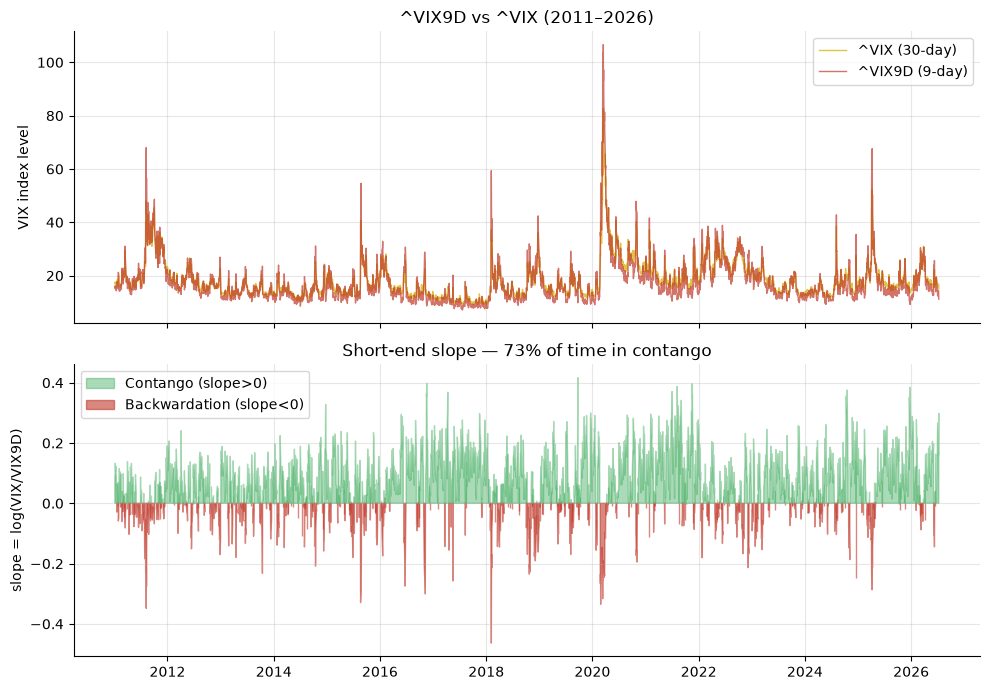

In [3]:
if HAVE_REAL:
    fig, axes = plt.subplots(2, 1, figsize=(10, 7), sharex=True)
    axes[0].plot(df.index, df['VIX'], label='^VIX (30-day)', color=AMBER, lw=1, alpha=0.8)
    axes[0].plot(df.index, df['VIX9D'], label='^VIX9D (9-day)', color=RED, lw=1, alpha=0.7)
    axes[0].set_ylabel('VIX index level'); axes[0].legend(); axes[0].set_title('^VIX9D vs ^VIX (2011–2026)')
    axes[1].fill_between(df.index, df['slope'], 0,
        where=(df['slope'] >= 0), color=GREEN, alpha=0.4, label='Contango (slope>0)')
    axes[1].fill_between(df.index, df['slope'], 0,
        where=(df['slope'] < 0), color=RED, alpha=0.6, label='Backwardation (slope<0)')
    axes[1].set_ylabel('slope = log(VIX/VIX9D)'); axes[1].legend()
    axes[1].set_title(f'Short-end slope — {R["frac_contango"]*100:.0f}% of time in contango')
    plt.tight_layout(); plt.show()
else:
    print(f'Real tape not cached. Headlines: N={R["n"]}, {R["date_start"]} to {R["date_end"]}')
    print('Fraction in contango: 73%')

The front end is in contango **73%** of the time — but notice how much *more* often it inverts than the 3-month curve (Study 111's ^VIX/^VIX3M slope sat in contango ~90% of the time). The 9-day tenor flips into backwardation on any scare: not just the big crises (2015 August, 2018 Volmageddon, 2020 COVID, 2022, 2025) but dozens of one- and two-day headline wobbles. These are the episodes the signal says to 'go defensive' — and many are followed by prompt recoveries.

**Now the key test: do contango days predict better next-day SPY returns?**

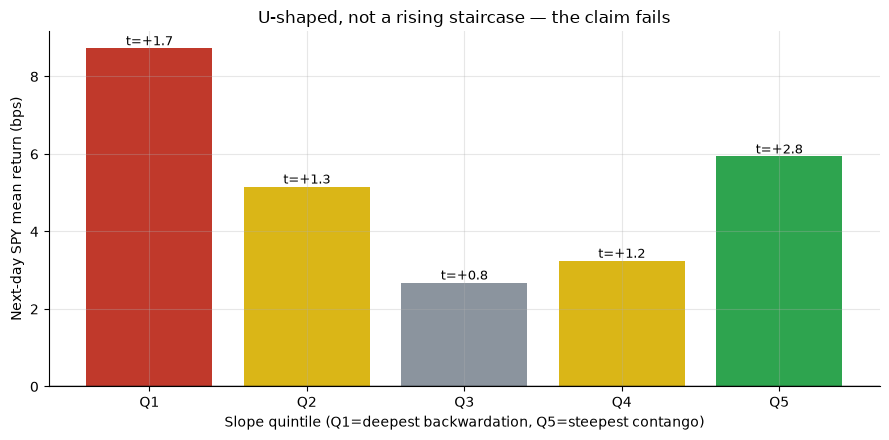

Predicted pattern: Q1 < Q2 < Q3 < Q4 < Q5
Actual: Q1=8.7 Q2=5.2 Q3=2.7 Q4=3.2 Q5=5.9


In [4]:
if HAVE_REAL:
    tbl = st.quintile_table(df, horizons=[1])
    means = [tbl[tbl['quintile']==q]['mean_bps'].values[0] for q in range(1,6)]
    tstats = [tbl[tbl['quintile']==q]['t_stat'].values[0] for q in range(1,6)]
else:
    means = [8.73, 5.16, 2.68, 3.25, 5.94]
    tstats = [1.65, 1.33, 0.79, 1.17, 2.8]
fig, ax = plt.subplots(figsize=(9, 4.5))
bars = ax.bar([f'Q{i}' for i in range(1,6)], means, color=[RED,AMBER,GREY,AMBER,GREEN])
ax.axhline(0, c='k', lw=1)
for b, t in zip(bars, tstats):
    ax.annotate(f't={t:+.1f}', (b.get_x()+b.get_width()/2, b.get_height()),
                ha='center', va='bottom', fontsize=9)
ax.set_xlabel('Slope quintile (Q1=deepest backwardation, Q5=steepest contango)')
ax.set_ylabel('Next-day SPY mean return (bps)')
ax.set_title('U-shaped, not a rising staircase — the claim fails')
plt.tight_layout(); plt.show()
print('Predicted pattern: Q1 < Q2 < Q3 < Q4 < Q5')
print(f'Actual: Q1={means[0]:.1f} Q2={means[1]:.1f} Q3={means[2]:.1f} Q4={means[3]:.1f} Q5={means[4]:.1f}')

There is no rising staircase. The shape is **U-shaped**: the two *extremes* — deep backwardation (Q1, **+8.7 bps**) and steep contango (Q5, **+5.9 bps**) — both beat the flat middle (Q3, +2.7 bps). But Q1 (the 'danger' bucket) actually earns *more* than Q5 (the 'all-clear'). The Q5-Q1 spread is **-2.79 bps** with HAC t = **-0.35**: consistent with zero and pointing the wrong way.

**The timing overlay — long in contango, flat when the front end inverts:**

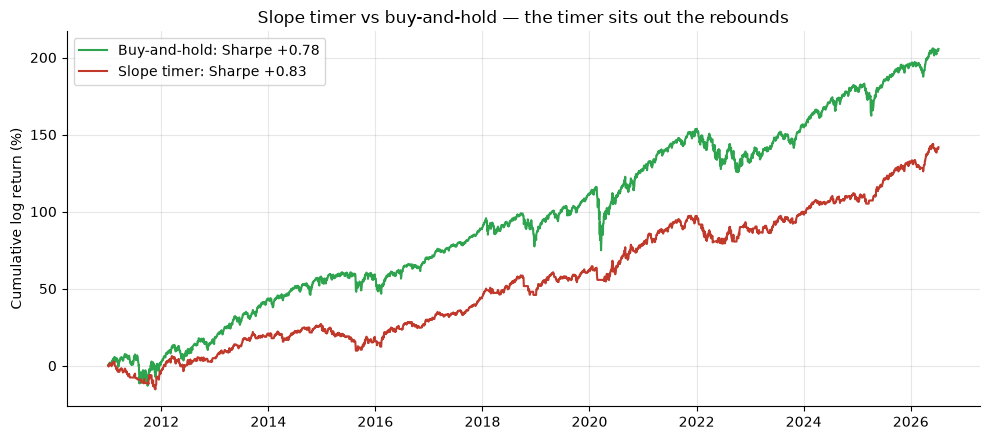

In [5]:
if HAVE_REAL:
    ov = st.timing_overlay(df, horizon=1, cost_bps=0.0)
    cum_active = ov['r_active'].cumsum() * 100
    cum_passive = ov['r_passive'].cumsum() * 100
    sa = st.summarize(ov['r_active']); sp = st.summarize(ov['r_passive'])
    act_m, act_sh, pas_m, pas_sh = sa['mean_bps'], sa['sharpe_ann'], sp['mean_bps'], sp['sharpe_ann']
else:
    act_m, act_sh, pas_m, pas_sh = 3.64, 0.83, 5.27, 0.78
    cum_active = cum_passive = None
fig, ax = plt.subplots(figsize=(10, 4.5))
if cum_active is not None:
    ax.plot(ov.index, cum_passive, label=f'Buy-and-hold: Sharpe {pas_sh:+.2f}', color=GREEN, lw=1.5)
    ax.plot(ov.index, cum_active, label=f'Slope timer: Sharpe {act_sh:+.2f}', color=RED, lw=1.5)
    ax.set_ylabel('Cumulative log return (%)')
    ax.set_title('Slope timer vs buy-and-hold — the timer sits out the rebounds')
    ax.legend(); plt.tight_layout(); plt.show()
else:
    print(f'Timer: {act_m:+.2f} bps/day, Sharpe {act_sh:+.2f}')
    print(f'Passive: {pas_m:+.2f} bps/day, Sharpe {pas_sh:+.2f}')

The timing overlay earns **+3.64 bps/day** (Sharpe +0.83) vs buy-and-hold's **+5.27 bps/day** (Sharpe +0.78). The timer trails by **~4.1%/yr** at zero cost. The reason is visible in the chart: the biggest equity gains in the sample happen right after the front-end inversions the timer classifies as 'danger'. By sitting in cash during those ~27% of days, the timer misses the very returns it was supposed to protect against losing — and it churns constantly getting in and out.

## 5 · The verdict

- **Signal — None.** Q5-Q1 spread is -2.79 bps (wrong sign), HAC *t* = -0.35 at 1 day; negative at all horizons tested; the quintile pattern is U-shaped, not monotone. The short-end slope does not forecast SPY *direction*.
- **Tradability — Mirage.** The timer trails buy-and-hold by 4.1%/yr at zero cost; ~37 switches/yr mean every bp of friction widens the gap, and by 5 bps/switch the underperformance is itself significant.
- **Beats buy-and-hold? — No.** Backwardation days average 6.0 bps/day (*more* than contango's 5.0 bps/day in raw terms) — the market rebounds hardest from the exact episodes the slope flags as most dangerous.

## 6 · Could you actually trade it?

Even if the spread were positive, the turnover arithmetic would sink it. The 9-day slope switches regimes ~37 times per year — nearly three times the churn of the 3-month curve — and each switch is a round-trip trade on the full SPY position. At realistic ETF round-trip costs:

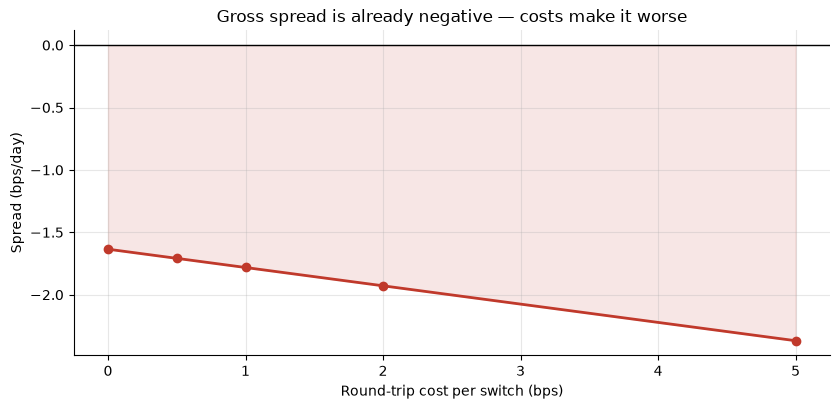

The slope timer underperforms buy-and-hold before costs; the heavy switching makes it worse.


In [6]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    spreads = []
    for c in costs:
        ov2 = st.timing_overlay(df, horizon=1, cost_bps=c)
        spreads.append(st.summarize(ov2['r_spread'])['mean_bps'])
else:
    spreads = [-1.64, -1.64-0.07, -1.64-0.14, -1.64-0.29, -1.64-0.73]
fig, ax = plt.subplots(figsize=(8.5, 4.2))
ax.plot(costs, spreads, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, spreads, 0, where=[s<0 for s in spreads], color=RED, alpha=.12)
ax.set_xlabel('Round-trip cost per switch (bps)'); ax.set_ylabel('Spread (bps/day)')
ax.set_title('Gross spread is already negative — costs make it worse')
plt.tight_layout(); plt.show()
print('The slope timer underperforms buy-and-hold before costs; the heavy switching makes it worse.')

The line starts below zero and only falls. Because the gross spread is already negative, **there is no switching cost low enough to make the timer competitive** with buying and holding. This is the strongest version of the 'Mirage' verdict: not 'dies at costs' but 'never lived' — and the high turnover only deepens the loss.

## 7 · Going further

- **Is the slope useful for anything?** Yes — for **volatility**, not direction. On a risk-adjusted basis contango days *are* calmer (Sharpe 0.97 vs 0.60). Signals that trade *volatility* (variance swaps, VIX-ETP roll harvesting) can use that; a signal that trades equity *direction* cannot.
- **The 3-month cousin.** The desk's [Study 111 — VIX-Term-Structure](../../111-vix-term-structure/) runs the identical test on the ^VIX/^VIX3M slope and reaches the same verdict — but with a third of the switching, so the front-end version studied here is *strictly worse* to trade.
- **What about VIX *level* mean-reversion?** VIX above 30 is statistically followed by higher SPY returns (the Connors/Alvarez literature), but that is the *level* of fear, not the slope between tenors — a separate claim.

*Convinced the short-end slope works on a different horizon or instrument? Fork this, change the parameters, and show a positive Q5-Q1 spread that clears the |t| ≥ 2 bar. That's the standard.*